For Project 3, we are operating under the following scenario:

An external online retail company, Le Shoppe, has requested assistance with identifying customers who may previously have shopped with their business, but haven't come back in a while.

They currently have limited outreach to these customers. 
- Once a year, their Marketing team runs a "welcome back" campaign where they send an email with a special discount code to customers who haven't shopped with them in 12 months.
- During quiet periods (when there aren't a lot of calls or tickets to respond to), their Customer Care team members are given a list to work from containing customer details who have been less active. The Customer Care team reach out to these customers and make contact with them, and are authorised to give them discounts and freebies where needed.

This company, Le Shoppe, has noticed recently that this is not the most effective means of reaching out to or identifying these customers. Both methods require a manual pull of a list from the system each time they need that list, and it requires someone on these teams with the knowledge and authority within the business to pull said list. The list may also be outdated by the time it reaches a customer care team member, or a resulting special offer has reached a customer.

The company is also unclear on what may be causing customers to stop shopping with them beyond individual feedback they have received from customers themselves. 

Le Shoppe has three primary goals for this particular endeavour:
1. A better process for identifying customers at risk of churning
2. Where possible, locate the underlying trend(s) that may be causing customers to churn
3. Suggestions and recommendations on how to improve their service to these customers

The primary stakeholders within Le Shoppe are the General Marketing Manager, the Customer Care Manager, and the Ecommerce Operations Manager.

## Marking Criteria (Notebook, 35%)
>  - A single professional and structured Jupyter notebook (pretend that you are submitting this to a potential client)
> - Include some EDA where needed, but focus primarily on robust experimentation with feature engineering, a variety of algorithms
> and their tuning, XAI, and providing rich analysis and interpretation at each step.
> - Make sure that you use a rich array of evaluation metrics and present all your modelling and accuracies from different approaches effectively.

## Notebook Sections

### Data Wrangling
1. <a id='part1a'>Churn dataset</a>: 
    - [Random Forest used initially](#datap_rf) for feature importances, paired with Correlation Matrix Heat Map for initial feature selection
        - [Fig 1](#fig1): Correlation Matrix Heat Map
    - [KMeans Clustering](#km_clustering) used to identify number of risk groups
        - [Fig 2](#fig2): Cluster Evaluation Metrics vs. Number of Clusters (k)
        - [Fig 3](#fig3): K-Means Clusters via UMAP
        - [Table 1](#Table1): Summary Statistics for Churn Data
        - [Table 2](#Table2): Cluster Summary
    - [Random Forest used again](#datap_rf2) to identify which features were the most important for kMeans clustered groups
        - [Fig 4](#fig4): Correlation Matrix Heat Map 2
    - **Feature selection**: features were selected from the above processes, and were based on feature importances, correlations, and relevance to groups determined by KMeans Clustering. The final set of features selected can be seen [here](#churn_feature_selection). 
2. <a id='part1b'>Customer Acquistion Cost dataset</a>: 
    - Features engineered:
        - CAC (Customer Acquisition Cost)
        - ROI (Return on Investment)
        - [Table 3](#Table3): Customer Acquisition Cost by Marketing Channel

### Modelling <a id="part2">
1. [CatBoost](#catboost)
    - Hyperparameter Tuning
        - [Depth](#cb_ht_depth)
        - [Number of Iterations](#cb_ht_cb_ht_iterations)
        - [Learning Rate](#cb_ht_lr)
        - [Early Stopping Rounds](#cb_ht_es)
        - [Grow Policy](#cb_ht_gp)
        - [Regularisation](#cb_ht_re) (includes L2 regularisation, random strength and bagging temperature)
        - [Fig 5](#Fig5): CatBoost Training History (Best GridSearch Parameters) <span style="color:red;">[interpretation needed]</span>
    - XAI with CatBoost
        - [Fig 6](#Fig6): SHAP Beeswarm Plot
        - [Fig 7](#Fig7): SHAP value for Cart_Abandonment_Rate
        - [Fig 8](#Fig8): SHAP value for Lifetime_Value
            - [Additional](#fig8_additional): Deep dive into the split

### Data Source(s)
- Singh, D. (n.d.). _Ecommerce Customer Behavior Dataset_. [Data set]. Kaggle. https://www.kaggle.com/datasets/dhairyajeetsingh/ecommerce-customer-behavior-dataset/data
- Hussam, A. (n.d.). _Customer Acquisition Cost Dataset_. [Data set]. Kaggle. https://www.kaggle.com/datasets/akramhussam/customer-acquisition-cost-dataset

### References
- _What is customer lifetime value (CLV)?_ https://www.ibm.com/think/topics/customer-lifetime-value
- _Customer Acquisition Cost (CAC)_ https://corporatefinanceinstitute.com/resources/accounting/customer-acquisition-cost-cac/

### Data and User-Defined Functions

In [120]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import shap

In [2]:
# Get ratio
def get_ratio(a, b):
    decimal_ratio = a / b
    
    return f"{decimal_ratio:.1f}:1"

# Define risk thresholds
def assign_risk_tier(prob, lowtier, medtier):
    if prob < lowtier:
        return 'Low'
    elif prob < medtier:
        return 'Med'
    else:
        return 'High'

def determine_best_risk_thresholds(y_proba, y_test, low_thresholds, med_thresholds, chosen_metric='f1_low'):
    y_test_mapped = np.where(y_test == 0, 'Low', 'High')
    results_list = []
    
    for low_t in low_thresholds:
        for med_t in med_thresholds:
            if low_t >= med_t:
                continue
                
            y_pred_risk = np.array([assign_risk_tier(p, low_t, med_t) for p in y_proba])
            
            # Get classification report as dict object
            report = classification_report(y_test_mapped,y_pred_risk,labels=['Low', 'Med', 'High'],zero_division=0,output_dict=True)
            
            # Save the parameters from this test into a dict row
            results_list.append({
                'low_cutoff': low_t,
                'med_cutoff': med_t,
                'precision (low)': report['Low']['precision'],
                'recall (low)': report['Low']['recall'],
                'f1-score (low)': report['Low']['f1-score'],
                'precision (high)': report['High']['precision'],
                'recall (high)': report['High']['recall'],
                'f1-score (high)': report['High']['f1-score'],
                'accuracy': report['accuracy']
            })
            
    # Put all the test results into a dataframe
    df_results = pd.DataFrame(results_list)
    
    # Select metric to define as 'best'
    if chosen_metric == 'f1_low':
        target_metric = 'f1-score (low)'
    elif chosen_metric == 'f1_high':
        target_metric = 'f1-score (high)'
    elif chosen_metric == 'precision_low':
        target_metric = 'precision (low)'
    elif chosen_metric == 'precision_high':
        target_metric = 'precision (high)'
    elif chosen_metric == 'recall_low':
        target_metric = 'recall (low)'
    elif chosen_metric == 'recall_high':
        target_metric = 'recall (high)'
    elif chosen_metric == 'accuracy':
        target_metric = 'accuracy'

    # Get the best row
    df_best = df_results.sort_values(by=target_metric, ascending=False).head(1)

    results = pd.DataFrame({"Metric": ["Precision","Recall","F1 Score"],
               "Low": [df_best['precision (low)'].iloc[0], df_best['recall (low)'].iloc[0], df_best['f1-score (low)'].iloc[0]],
               "High": [df_best['precision (high)'].iloc[0], df_best['recall (high)'].iloc[0], df_best['f1-score (high)'].iloc[0]]})

    results.set_index('Metric', inplace=True)
    results.index.rename('', inplace=True)
    print(f"""Best Results
----------------------------------------------
Low threshold: {df_best['low_cutoff'].iloc[0]}
Medium threshold: {df_best['med_cutoff'].iloc[0]}
Accuracy: {df_best['accuracy'].iloc[0]}
{results}""")

---

# Churn

In [3]:
churn_dataset = pd.read_csv('datasets/ecommerce_customer_churn_dataset.csv')

In [4]:
churn_dataset.dtypes

Age                              float64
Gender                            object
Country                           object
City                              object
Membership_Years                 float64
Login_Frequency                  float64
Session_Duration_Avg             float64
Pages_Per_Session                float64
Cart_Abandonment_Rate            float64
Wishlist_Items                   float64
Total_Purchases                  float64
Average_Order_Value              float64
Days_Since_Last_Purchase         float64
Discount_Usage_Rate              float64
Returns_Rate                     float64
Email_Open_Rate                  float64
Customer_Service_Calls           float64
Product_Reviews_Written          float64
Social_Media_Engagement_Score    float64
Mobile_App_Usage                 float64
Payment_Method_Diversity         float64
Lifetime_Value                   float64
Credit_Balance                   float64
Churned                            int64
Signup_Quarter  

In [5]:
churn_dataset.isna().sum()

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

<a id='datap_rf'> </a>
How many of these features are 'important' (and how many of them can we just delete if they're not and contain too many NaNs)? <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

In [6]:
# Random Forest Classifier doesn't like categorical values
encoder = OneHotEncoder(sparse_output=False)
encoded_array = encoder.fit_transform(churn_dataset[['Gender','Country','City','Signup_Quarter']])

encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['Gender','Country','City','Signup_Quarter']))
churn_dataset_encoded = churn_dataset.drop(['Gender','Country','City','Signup_Quarter'], axis=1)
churn_dataset_encoded = pd.concat([churn_dataset_encoded, encoded_df], axis=1)

In [7]:
y = churn_dataset_encoded['Churned']
X = churn_dataset_encoded.drop('Churned', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
rf_helper = RandomForestClassifier(n_estimators=100, random_state=42)
rf_helper.fit(X_train, y_train)

importances = rf_helper.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

In [9]:
top20feature_importance_df = feature_importance_df.head(20)
top20feature_importance_df

,Feature,Importance
18,Lifetime_Value,0.111573
13,Customer_Service_Calls,0.104860
5,Cart_Abandonment_Rate,0.081476
0,Age,0.062750
10,Discount_Usage_Rate,0.057891
9,Days_Since_Last_Purchase,0.051831
12,Email_Open_Rate,0.046456
8,Average_Order_Value,0.044633
7,Total_Purchases,0.043806
3,Session_Duration_Avg,0.042794


<a id='fig1'>Fig 1</a>: Correlation Matrix Heat Map <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

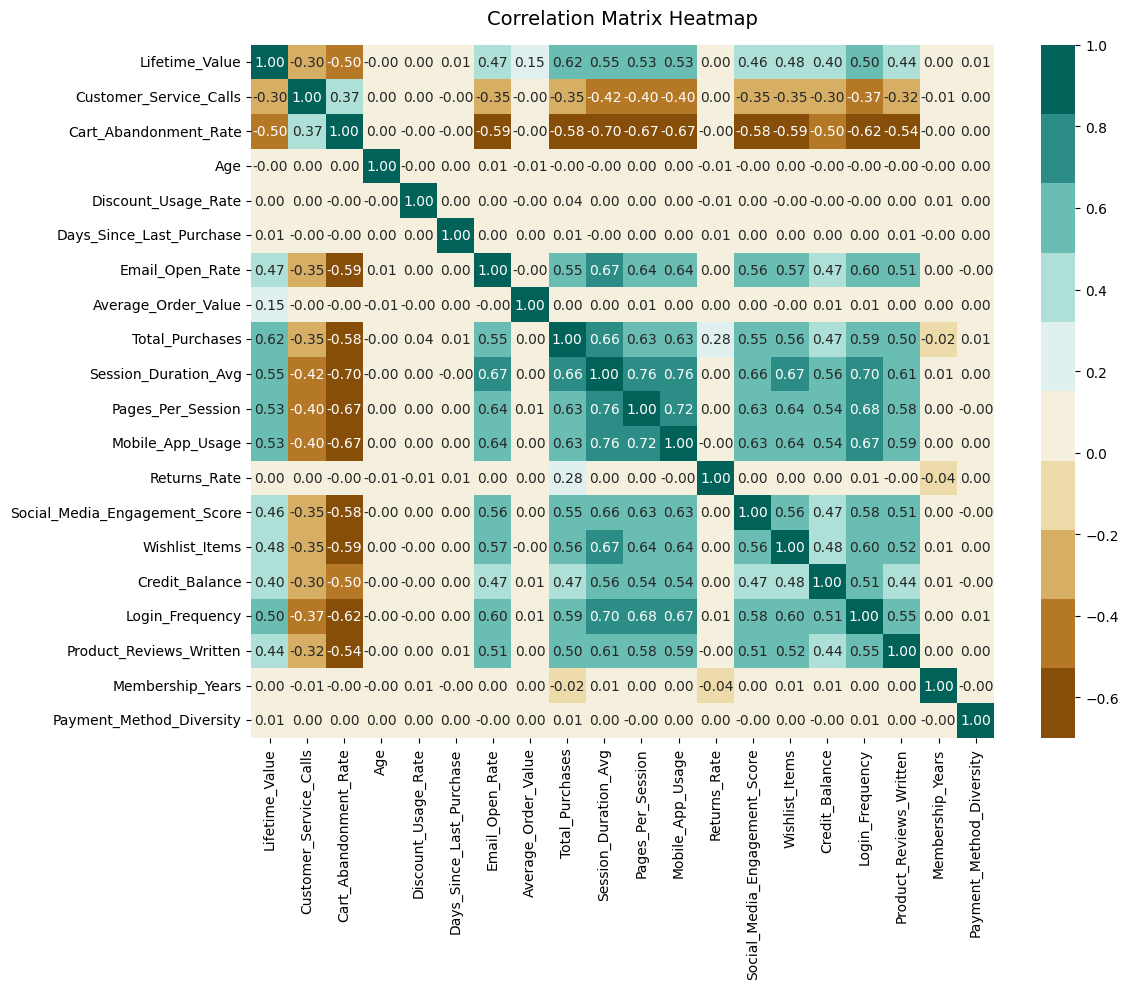

In [10]:
feature_names_top20 = top20feature_importance_df['Feature'].tolist()

corr_matrix = churn_dataset_encoded[feature_names_top20].corr()

plt.figure(figsize=(12, 10))
colormap = sns.color_palette("BrBG",10)

# Draw the heatmap
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap=colormap)

plt.title("Correlation Matrix Heatmap", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Based on the above diagnostics, these are the best features to select/work with, so far:

**Strongest feature:** Lifetime_Value

**Supporting features (highest correlation):**
- Total_Purchases
- Session_Duration_Average
- Pages_Per_Session
- Mobile_App_Usage
- Login_Frequency
- Cart_Abandonment_Rate

**Possibly Helpful/Remains to be seen (moderate correlation)**
- Social_Media_Engagement_Score
- Wishlist_Items
- Credit_Balance
- Product_Reviews_Written
- Email_Open_Rate

**Questionable/Not Super Helpful (low correlation):**
- Average_Order_Value
- Returns_Rate
- Customer_Service_Calls

**Features we can absolutely drop (nil or next-to-nil correlation):**
- Age
- Discount_Usage_Rate
- Days_Since_Last_Purchase
- Membership_Years
- Payment_Method_Diversity

In [11]:
columns_to_initially_keep = ['Gender','Country','City'] + feature_names_top20 + ['Churned']
churn_df = churn_dataset[columns_to_initially_keep]
columns_to_drop = ['Age','Discount_Usage_Rate','Days_Since_Last_Purchase','Membership_Years','Payment_Method_Diversity','Customer_Service_Calls']
churn_df = churn_df.drop(columns=columns_to_drop)
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Gender                         50000 non-null  object 
 1   Country                        50000 non-null  object 
 2   City                           50000 non-null  object 
 3   Lifetime_Value                 50000 non-null  float64
 4   Cart_Abandonment_Rate          50000 non-null  float64
 5   Email_Open_Rate                47472 non-null  float64
 6   Average_Order_Value            50000 non-null  float64
 7   Total_Purchases                50000 non-null  float64
 8   Session_Duration_Avg           46601 non-null  float64
 9   Pages_Per_Session              47000 non-null  float64
 10  Mobile_App_Usage               45000 non-null  float64
 11  Returns_Rate                   45509 non-null  float64
 12  Social_Media_Engagement_Score  44000 non-null 

---

## Risk Group Identification

<a id='km_clustering'> </a>
### Kmeans Clustering

As a means of identifying how to split our dataset for prediction analysis, we are employing the KMeans Clustering algorithm to see how we can best segregate the customers, and how many risk groups we can split them into.

<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

In [12]:
# Keep only continuous labels (no categorical/encoded)
# Drop the nil correlations
kmeans_df = churn_dataset.drop(columns=['Age','Gender','Country','City','Signup_Quarter','Returns_Rate','Discount_Usage_Rate','Days_Since_Last_Purchase','Membership_Years','Payment_Method_Diversity','Customer_Service_Calls']).copy()
kmeans_df.dropna(inplace=True) # Drops nearly half the dataset, just FYI
y_kmeans = kmeans_df['Churned']
X_kmeans = kmeans_df.drop('Churned', axis=1)

scaler = StandardScaler()
X_kmeans_scaled = scaler.fit_transform(X_kmeans)

Use indexing to see the optimal number of groups

In [13]:
k_range = range(2, 7) # Check range of 2 - 7 clusters
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for k in k_range:
    km_model = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km_model.fit(X_kmeans_scaled)
    results = km_model.predict(X_kmeans_scaled)

    silhouette_scores.append(metrics.silhouette_score(X_kmeans_scaled, results))
    davies_bouldin_scores.append(metrics.davies_bouldin_score(X_kmeans_scaled, results))
    calinski_harabasz_scores.append(metrics.calinski_harabasz_score(X_kmeans_scaled, results))

<a id='fig2'>Fig 2</a>: Cluster Evaluation Metrics vs. Number of Clusters (k) <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

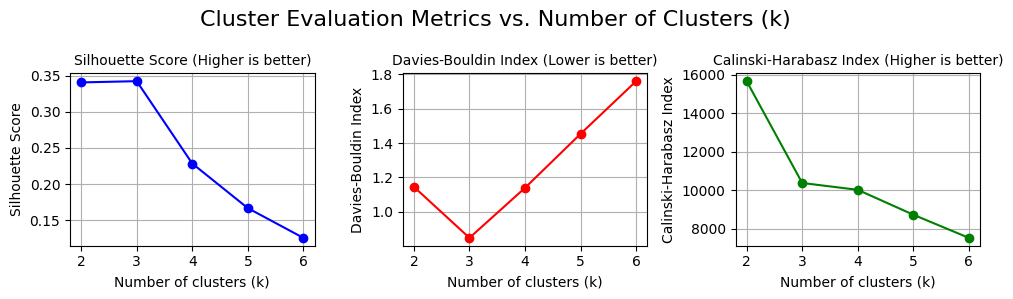

In [14]:
fig = plt.figure(figsize=(10, 3))
gs = gridspec.GridSpec(1, 3, figure=fig, height_ratios=[1])
fig.suptitle('Cluster Evaluation Metrics vs. Number of Clusters (k)', fontsize=16)

ax1 = fig.add_subplot(gs[0, 0]) # Row 0, Column 0
# Silhouette Plot
ax1.plot(k_range, silhouette_scores, 'bo-')
ax1.set_xlabel('Number of clusters (k)', fontsize=10)
ax1.set_ylabel('Silhouette Score', fontsize=10)
ax1.set_title('Silhouette Score (Higher is better)', fontsize=10)
ax1.grid(True)

ax2 = fig.add_subplot(gs[0, 1]) # Row 0, Column 1
# Davies-Bouldin Plot
ax2.plot(k_range, davies_bouldin_scores, 'ro-')
ax2.set_xlabel('Number of clusters (k)', fontsize=10)
ax2.set_ylabel('Davies-Bouldin Index', fontsize=10)
ax2.set_title('Davies-Bouldin Index (Lower is better)', fontsize=10)
ax2.grid(True)

ax3 = fig.add_subplot(gs[0, 2]) # Row 0, Column 2
# Calinski-Harabasz Plot
ax3.plot(k_range, calinski_harabasz_scores, 'go-')
ax3.set_xlabel('Number of clusters (k)', fontsize=10)
ax3.set_ylabel('Calinski-Harabasz Index', fontsize=10)
ax3.set_title('Calinski-Harabasz Index (Higher is better)', fontsize=10)
ax3.grid(True)

plt.tight_layout(); plt.show()

From the above plots, we can determine the optimal number for k is most likely 3. 3 is (just barely) the highest Silhouette Score, the lowest (preferred) option in the Davies-Bouldin Index, and the 'elbow' in the Calinski-Harabasz Index (where the rate of improvement is minimal past this point as k increases).

In [15]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)

cluster_labels = kmeans.fit_predict(X_kmeans_scaled)

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_kmeans_scaled)

<a id='fig3'>Fig 3</a>: K-Means Clusters via UMAP <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

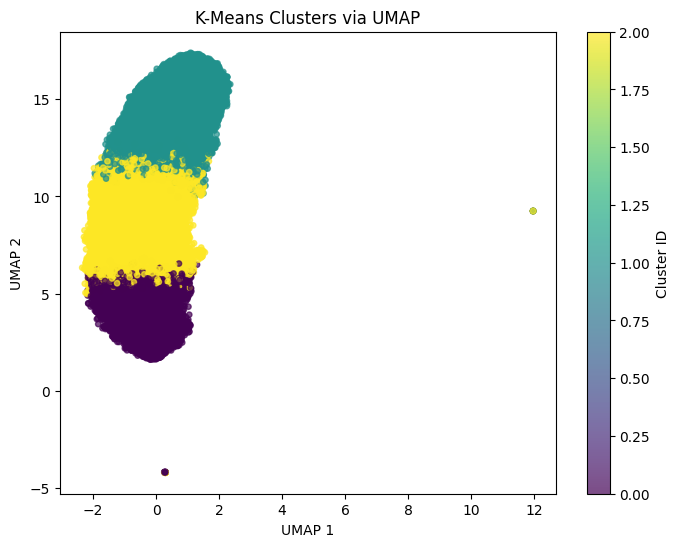

In [16]:
plt.figure(figsize=(8, 6)); scatter = plt.scatter(X_umap[:, 0],X_umap[:, 1],c=cluster_labels,cmap="viridis",s=15,alpha=0.7)
plt.colorbar(scatter, label="Cluster ID"); plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2"); plt.title("K-Means Clusters via UMAP"); plt.show()

Most of the data forms a single bean structure along the UMAP coordinates. This is probably reflective of continuous data, rather than distinctly separated groups. There are a couple of outliers which may require a bit of looking into to see if they're valid, or not.

There are weird slices, instead of groups/clusters, and there aren't really any clear "gaps" between the data points. There might be a bit of overlap between the groups identified, depending on the data point.

In [17]:
kmean_groups = X_kmeans.copy(); kmean_groups['Cluster'] = cluster_labels
kmean_groups['Churned'] = y_kmeans

# Calculate the average values for each cluster
cluster_summary = kmean_groups.groupby('Cluster').mean(); 
cluster_table = cluster_summary.sort_values(by='Churned', ascending=True)

In [18]:
summary_values = {"Feature": ['Login_Frequency','Session_Duration_Avg', 'Pages_Per_Session', 'Wishlist_Items', 
                          'Total_Purchases','Average_Order_Value','Email_Open_Rate','Product_Reviews_Written',
                          'Social_Media_Engagement_Score','Mobile_App_Usage','Lifetime_Value','Credit_Balance','Churned'],
    "Min": [kmeans_df.Login_Frequency.min(), kmeans_df.Session_Duration_Avg.min(), kmeans_df.Pages_Per_Session.min(), kmeans_df.Wishlist_Items.min(), kmeans_df.Total_Purchases.min(), kmeans_df.Average_Order_Value.min(), kmeans_df.Email_Open_Rate.min(), kmeans_df.Product_Reviews_Written.min(), kmeans_df.Social_Media_Engagement_Score.min(), kmeans_df.Mobile_App_Usage.min(), kmeans_df.Lifetime_Value.min(), kmeans_df.Credit_Balance.min(), kmeans_df.Churned.min()],
    "Q1": [kmeans_df.Login_Frequency.quantile(0.25), kmeans_df.Session_Duration_Avg.quantile(0.25), kmeans_df.Pages_Per_Session.quantile(0.25), kmeans_df.Wishlist_Items.quantile(0.25), kmeans_df.Total_Purchases.quantile(0.25), kmeans_df.Average_Order_Value.quantile(0.25), kmeans_df.Email_Open_Rate.quantile(0.25), kmeans_df.Product_Reviews_Written.quantile(0.25), kmeans_df.Social_Media_Engagement_Score.quantile(0.25), kmeans_df.Mobile_App_Usage.quantile(0.25), kmeans_df.Lifetime_Value.quantile(0.25), kmeans_df.Credit_Balance.quantile(0.25), kmeans_df.Churned.quantile(0.25)],
    "Median": [kmeans_df.Login_Frequency.median(), kmeans_df.Session_Duration_Avg.median(), kmeans_df.Pages_Per_Session.median(), kmeans_df.Wishlist_Items.median(), kmeans_df.Total_Purchases.median(), kmeans_df.Average_Order_Value.median(), kmeans_df.Email_Open_Rate.median(), kmeans_df.Product_Reviews_Written.median(), kmeans_df.Social_Media_Engagement_Score.median(), kmeans_df.Mobile_App_Usage.median(), kmeans_df.Lifetime_Value.median(), kmeans_df.Credit_Balance.median(), kmeans_df.Churned.median()],    
    "Q3": [kmeans_df.Login_Frequency.quantile(0.75), kmeans_df.Session_Duration_Avg.quantile(0.75), kmeans_df.Pages_Per_Session.quantile(0.75), kmeans_df.Wishlist_Items.quantile(0.75), kmeans_df.Total_Purchases.quantile(0.75), kmeans_df.Average_Order_Value.quantile(0.75), kmeans_df.Email_Open_Rate.quantile(0.75), kmeans_df.Product_Reviews_Written.quantile(0.75), kmeans_df.Social_Media_Engagement_Score.quantile(0.75), kmeans_df.Mobile_App_Usage.quantile(0.75), kmeans_df.Lifetime_Value.quantile(0.75), kmeans_df.Credit_Balance.quantile(0.75), kmeans_df.Churned.quantile(0.75)],
    "Max": [kmeans_df.Login_Frequency.max(), kmeans_df.Session_Duration_Avg.max(), kmeans_df.Pages_Per_Session.max(), kmeans_df.Wishlist_Items.max(), kmeans_df.Total_Purchases.max(), kmeans_df.Average_Order_Value.max(), kmeans_df.Email_Open_Rate.max(), kmeans_df.Product_Reviews_Written.max(), kmeans_df.Social_Media_Engagement_Score.max(), kmeans_df.Mobile_App_Usage.max(), kmeans_df.Lifetime_Value.max(), kmeans_df.Credit_Balance.max(), kmeans_df.Churned.max()]}

summary_stats = pd.DataFrame(summary_values)

<a id='Table1'>Table 1</a>: Summary Statistics for Churn Data <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

In [19]:
summary_stats.sort_values('Max', ascending=False).style.set_caption('Summary Statistics for Churn Data').format(precision=2)

,Feature,Min,Q1,Median,Q3,Max
5,Average_Order_Value,26.87,87.04,112.21,143.75,9487.43
10,Lifetime_Value,0.00,833.23,1299.56,1933.79,8987.24
11,Credit_Balance,0.00,1122.00,1987.00,2872.50,7160.00
4,Total_Purchases,-13.00,9.00,13.00,17.00,127.40
8,Social_Media_Engagement_Score,0.00,14.50,29.20,44.90,100.00
6,Email_Open_Rate,0.00,10.60,20.60,31.20,91.70
1,Session_Duration_Avg,1.00,20.10,27.30,35.20,72.10
9,Mobile_App_Usage,0.00,13.20,19.60,26.40,61.90
0,Login_Frequency,0.00,6.00,12.00,18.00,46.00
2,Pages_Per_Session,1.00,6.30,8.80,11.60,23.20


From the above, our outliers are probably coming from Average_Order_Value, Lifetime_Value or Credit_Balance. There does appear to be negative amount(s) for Total_Purchases which I am unclear on, but can only assume that's related to refunds.

<a id='Table2'>Table 2</a>: Cluster Summary <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

In [20]:
cluster_table.style.set_caption('Cluster Summary').format(precision=2)

,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Email_Open_Rate,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Lifetime_Value,Credit_Balance,Churned
Cluster,,,,,,,,,,,,,,
0,21.81,42.50,13.87,36.39,8.30,21.74,124.44,38.36,5.56,54.89,32.33,2418.30,3291.82,0.20
2,13.42,29.80,9.64,52.97,4.91,14.51,123.83,23.24,3.26,33.21,21.50,1580.46,2167.09,0.20
1,6.21,18.76,5.90,68.15,2.12,8.31,119.78,10.99,1.40,15.59,12.29,907.72,1249.04,0.38


Our 3 clusters do have pretty distinct average values, and show a clear overall pattern. There is a positive association between churn risk and cart_abandoment_rate, where the churn risk increases as the cart_abandonment_rate increases. There is a negative association between all other features and churn risk (where the feature (ie. Login_Frequency) increases, churn risk decreases). 

This shows there is some promise for being able to group the Churn dataset into 3 risk categories: low, medium and high (where low is a low risk of churn, and high is a high risk of churn).

In [21]:
risk_map = {0: "low", 1: "high", 2: "medium"}
kmean_groups['Churn_Risk'] = kmean_groups['Cluster'].map(risk_map)
kmean_groups.head(5)

,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Email_Open_Rate,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Lifetime_Value,Credit_Balance,Cluster,Churned,Churn_Risk
0,14.0,27.4,6.0,50.6,3.0,9.0,94.72,17.9,4.0,16.3,20.8,953.33,2278.0,2,0,medium
3,10.0,38.4,14.8,41.7,9.0,15.0,147.33,41.4,5.0,85.9,31.0,2340.92,2674.0,0,0,low
5,6.0,21.9,6.9,74.4,0.0,12.0,190.97,16.0,2.0,14.3,11.2,1995.43,2418.0,1,1,high
6,24.0,46.4,13.9,36.2,5.0,20.0,169.58,35.5,6.0,68.8,42.9,3003.57,2657.0,0,0,low
9,13.0,31.3,5.4,62.6,3.0,9.0,90.95,11.7,1.0,13.5,21.5,807.84,977.0,1,0,high


KMeans does not have 'probabilities', so we'll use GM to get the probabilities from the kmeans clustering results.

In [22]:
gmm = GaussianMixture(n_components=3, means_init=kmeans.cluster_centers_)
gmm.fit(X_kmeans_scaled) 

probabilities = gmm.predict_proba(X_kmeans_scaled)

prob_cols = [f'cluster_{i}_prob' for i in range(gmm.n_components)]
prob_df = pd.DataFrame(probabilities, columns=prob_cols, index=kmeans_df.index)

df_with_probs = pd.concat([kmeans_df, prob_df], axis=1)

prob_cols = ['cluster_0_prob', 'cluster_1_prob', 'cluster_2_prob']

df_with_probs['predicted_cluster'] = gmm.predict(X_kmeans_scaled)
df_with_probs['max_prob'] = df_with_probs[prob_cols].max(axis=1) # The highest probability out of each cluster

# Check the model's overall average confidence
baseline_confidence = df_with_probs['max_prob'].mean()

# Check the model's ambiguity rate (Customers the model struggled to place)
ambiguity_rate = (df_with_probs['max_prob'] < 0.60).mean()

# Extract customers where the baseline model is 95%+ confident
high_confidence_df = df_with_probs[df_with_probs['max_prob'] > 0.95]

# Extract customers where the baseline model is 70%+ confident
med_confidence_df = df_with_probs[(df_with_probs['max_prob'] > 0.70) & (df_with_probs['max_prob'] <= 0.95)]

# Extract customers where the baseline model is less than 70% confident
low_confidence_df = df_with_probs[df_with_probs['max_prob'] <= 0.70]

print(f"Baseline Average Confidence: {baseline_confidence:.2%}")
print(f"Baseline Ambiguity Rate: {ambiguity_rate:.2%}")
print(f"High Confidence Segments: {len(high_confidence_df)} out of {len(df_with_probs)} rows")
print(f"Medium Confidence Segments: {len(med_confidence_df)} out of {len(df_with_probs)} rows")
print(f"Low Confidence Segments: {len(low_confidence_df)} out of {len(df_with_probs)} rows")

Baseline Average Confidence: 91.96%
Baseline Ambiguity Rate: 4.75%
High Confidence Segments: 16494 out of 25123 rows
Medium Confidence Segments: 6162 out of 25123 rows
Low Confidence Segments: 2467 out of 25123 rows


In [23]:
low_confidence_indices = low_confidence_df.index
difficult_df = churn_df.iloc[low_confidence_indices]
difficult_df.to_csv('datasets/difficult_cases.csv')

<a id='datap_rf2'> </a>
Of the features used for grouping, which features are the biggest factors in deciding which groups kMeans has put each data point into? <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

In [24]:
y_labels = kmean_groups['Cluster']
X_features = kmean_groups.drop(['Cluster','Churned','Churn_Risk'], axis=1, errors='ignore')

rf_helper2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_helper2.fit(X_features, y_labels)

importances = rf_helper2.feature_importances_
feature_names = X_features.columns
feature_importance_df2 = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

feature_importance_df2 = feature_importance_df2.sort_values(by='Importance', ascending=False)
feature_importance_df2

,Feature,Importance
1,Session_Duration_Avg,0.174538
5,Total_Purchases,0.159901
10,Mobile_App_Usage,0.132064
2,Pages_Per_Session,0.117986
3,Cart_Abandonment_Rate,0.079248
0,Login_Frequency,0.066481
4,Wishlist_Items,0.058934
7,Email_Open_Rate,0.058292
9,Social_Media_Engagement_Score,0.044752
12,Credit_Balance,0.033638


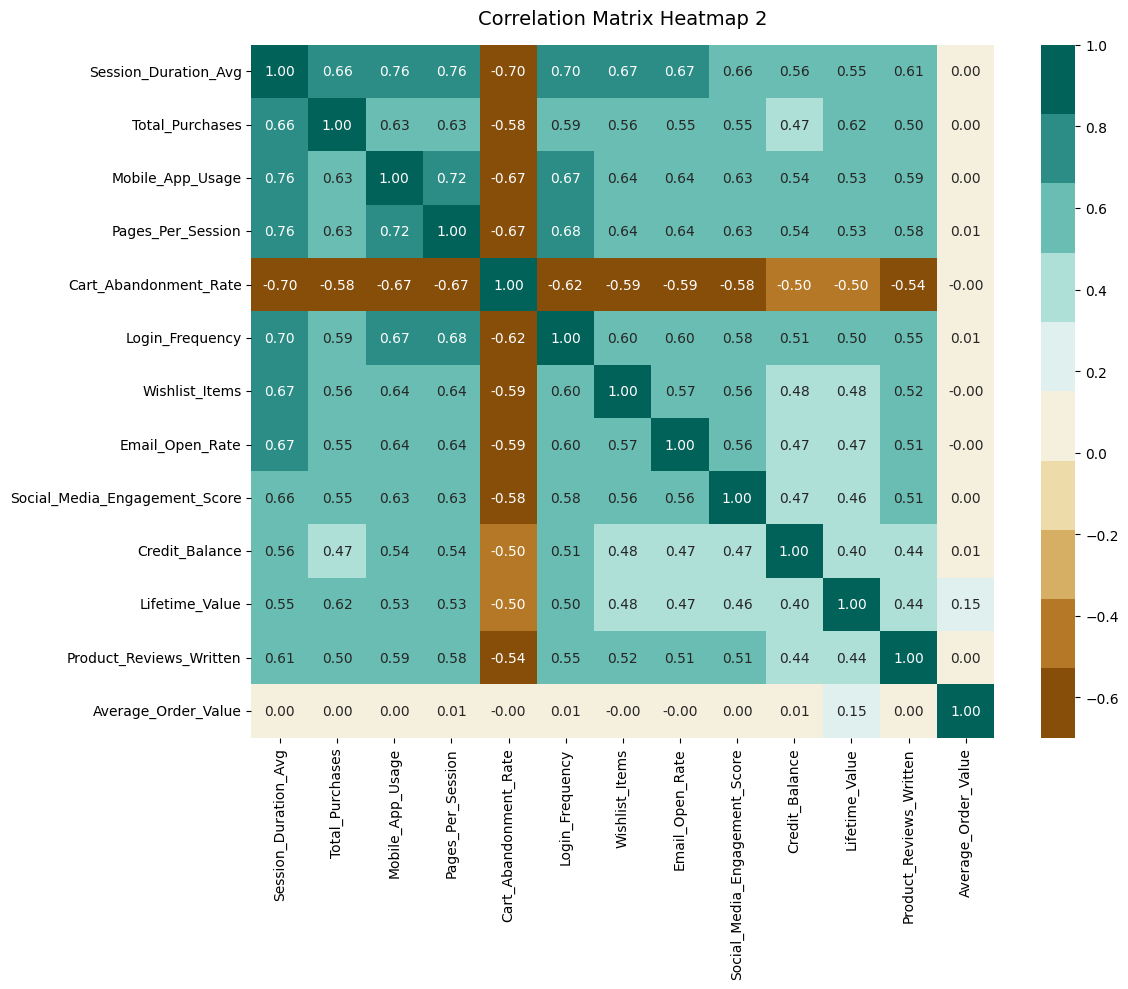

In [25]:
feature_names_grouping = feature_importance_df2['Feature'].tolist()

corr_matrix = churn_dataset_encoded[feature_names_grouping].corr()

plt.figure(figsize=(12, 10))
colormap = sns.color_palette("BrBG",10)

# Draw the heatmap
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap=colormap)

plt.title("Correlation Matrix Heatmap 2", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

When it comes to grouping, based on the initial KMeans Clustering results, the important features are:

**Supporting features (highest correlation):**
- Session_Duration_Avg
- Total_Purchases
- Mobile_App_Usage
- Pages_Per_Session
- Cart_Abandonment_Rate
- Login_Frequency
- Wishlist_Items
- Email_Open_Rate

**Probably helpful (moderate correlation)**
- Lifetime_Value
- Social_Media_Engagement_Score
- Credit_Balance
- Product_Reviews_Written

**Droppable (very low correlation):**
- Average_Order_Value

In [26]:
print(churn_dataset.columns)

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')


In [27]:
columns_to_keep = ['Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 
                   'Total_Purchases', 'Email_Open_Rate', 'Mobile_App_Usage', 'Lifetime_Value', 'Credit_Balance', 'Churned']
churn_df = churn_dataset[columns_to_keep]
churn_df.to_csv('datasets/churn_data_ready.csv')

<a id='churn_feature_selection'> </a>
Final feature selection: features were selected from the original Churn dataset via the above processes. Feature selection was based on the results of Random Forest feature importances, correlation heat maps, and relevance to groups determined by KMeans Clustering. <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1a))</span>

In [28]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Login_Frequency        50000 non-null  float64
 1   Session_Duration_Avg   46601 non-null  float64
 2   Pages_Per_Session      47000 non-null  float64
 3   Cart_Abandonment_Rate  50000 non-null  float64
 4   Wishlist_Items         46000 non-null  float64
 5   Total_Purchases        50000 non-null  float64
 6   Email_Open_Rate        47472 non-null  float64
 7   Mobile_App_Usage       45000 non-null  float64
 8   Lifetime_Value         50000 non-null  float64
 9   Credit_Balance         44500 non-null  float64
 10  Churned                50000 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 4.2 MB


---

<a id='part1b'> </a>
# Customer Acquisition Cost
While this is a smaller dataset, it should be helpful to illustrate the cost(s) of acquiring a new customer. The formula for this is
$$\text{Customer Acquisition Cost} = \frac{\text{Sales and Marketing Costs}}{\text{Number of New Customers}}$$

The thought process behind this is that when a customer churns, a company has to spend money on advertising all over again to acquire a new customer. This results in net-zero growth, rather than expansion.

In [29]:
customer_acquistion_cost_df = pd.read_csv('datasets/customer_acquisition_cost_dataset.csv')
customer_acquistion_cost_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_ID        500 non-null    object 
 1   Marketing_Channel  500 non-null    object 
 2   Marketing_Spend    500 non-null    float64
 3   New_Customers      500 non-null    int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 15.8+ KB


In [30]:
channel_data = customer_acquistion_cost_df.groupby('Marketing_Channel')[['Marketing_Spend','New_Customers']].sum()
channel_data['CAC'] = channel_data['Marketing_Spend'] / channel_data['New_Customers']
channel_data.reset_index(inplace=True)
average_cac = channel_data['CAC'].mean()
cac_metrics1 = {"Metric": ["Average CAC - all channels"] + [f" - {channel}" for channel in channel_data['Marketing_Channel']],
                "Value": [average_cac] + channel_data['CAC'].tolist()}
print(f"The average cost to acquire a new customer across all marketing channels is ${average_cac:.2f}")

The average cost to acquire a new customer across all marketing channels is $103.04


From the above, we can see that the average customer acquisition cost across all marketing channels is $103.04. This means that, for each new customer, the company is spending an average of $103.04 to acquire them. The actual cost per customer ranges between $99.78 (customers acquired through Online Ads) and $107.18 (for customers acquired via Email Marketing).

## Return on Investment
The Churn dataset provides a useful feature for calculating ROI: Lifetime_Value 

ROI(%) = $\frac{\text{Customer Revenue - CAC}}{\text{CAC}}\times100$

https://chartmogul.com/saas-metrics/ltv/

In [32]:
# Calculate Average Revenue Per Customer for original churn_df
average_revenue_per_customer = churn_dataset['Lifetime_Value'].mean()
print(f"The average revenue per customer is ${average_revenue_per_customer:.2f}")

The average revenue per customer is $1440.63


In [33]:
channel_data['ROI'] = ((average_revenue_per_customer - channel_data['CAC']) / channel_data['CAC']) * 100
cac_metrics2 = {"Metric": ["Return on Investment - all channels"] + [f" - {channel}" for channel in channel_data['Marketing_Channel']] + ["LTV:CAC Ratio"], 
                "Value": [channel_data['ROI'].mean()] + channel_data['ROI'].tolist() + [get_ratio(average_revenue_per_customer, channel_data['CAC'].iloc[0])]}

,Marketing_Channel,Marketing_Spend,New_Customers,CAC,ROI
0,Email Marketing,384034.640088,3583,107.182428,1244.088128
1,Online Ads,388747.870215,3896,99.781281,1343.784124
2,Referral,391420.513169,3904,100.261402,1336.870285
3,Social Media,383160.250917,3652,104.917922,1273.098385


<a id='Table3'>Table 3</a>: Customer Acquisition Cost by Marketing Channel <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part1b))</span>

In [ ]:
channel_data.style.set_caption('Customer Acquisition Cost by Marketing Channel').format(precision=2)

In [34]:
print(f"The LTV:CAC ratio is {get_ratio(average_revenue_per_customer, channel_data['CAC'].iloc[0])}")

The LTV:CAC ratio is 13.4:1


This means that for every $1 spent on Marketing, $13.40 is earned.

## Impacts of Churn on Revenue
$\text{Revenue Churn} = (\frac{\text{Lost Revenue from Churned Customers}}{\text{Total Revenue at Start}})\times100$



In [35]:
cac_metrics1, cac_metrics2

({'Metric': ['Average CAC - all channels',
   ' - Email Marketing',
   ' - Online Ads',
   ' - Referral',
   ' - Social Media'],
  'Value': [np.float64(103.03575822248665),
   107.18242815727515,
   99.78128085607146,
   100.26140193874531,
   104.91792193785471]},
 {'Metric': ['Return on Investment - all channels',
   ' - Email Marketing',
   ' - Online Ads',
   ' - Referral',
   ' - Social Media',
   'LTV:CAC Ratio'],
  'Value': [np.float64(1299.4602306557013),
   1244.0881278469299,
   1343.7841242767947,
   1336.870285217187,
   1273.0983852818931,
   '13.4:1']})

In [36]:
churned_customers = (churn_dataset['Churned'] == 1).sum()

In [37]:
total_customers = len(churn_dataset)
churn_rate = churned_customers / total_customers
print(f"The overall churn rate is {churn_rate:.2%}")

The overall churn rate is 28.90%


In [38]:
# Looking only at customers with more than one purchase
customers_with_more_than_one_purchase = churn_dataset[churn_dataset['Total_Purchases'] > 1]
customers_with_more_than_one_purchase.shape

(49815, 25)

In [39]:
churned_grouping = pd.DataFrame(churn_dataset['Days_Since_Last_Purchase'].groupby(churn_dataset['Churned']).value_counts())
churned_grouping.reset_index(inplace=True)
churn_group_churned = churned_grouping[churned_grouping['Churned'] == 1]

churned_group = pd.DataFrame({"Min": [churn_group_churned['Days_Since_Last_Purchase'].min()],
                              "Q1": [churn_group_churned['Days_Since_Last_Purchase'].quantile(0.25)],
                              "Median": [churn_group_churned['Days_Since_Last_Purchase'].median()],
                              "Q3": [churn_group_churned['Days_Since_Last_Purchase'].quantile(0.75)],
                              "Max": [churn_group_churned['Days_Since_Last_Purchase'].max()]})
churned_group

,Min,Q1,Median,Q3,Max
0,0.0,56.0,112.0,168.0,287.0


50% of customers churn at 112 days since their last purchase.

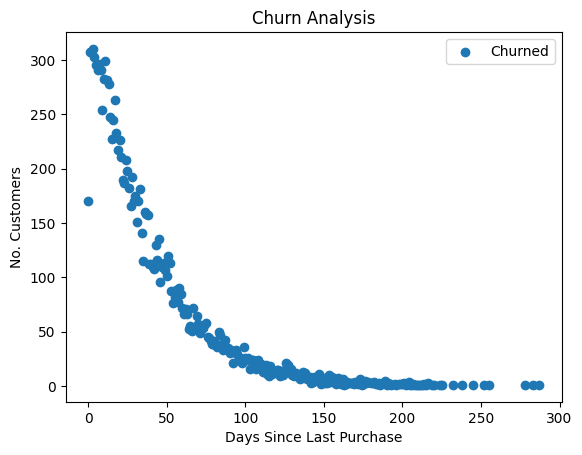

In [40]:
plt.scatter(churn_group_churned['Days_Since_Last_Purchase'], churn_group_churned['count'], label='Churned')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('No. Customers')
plt.title('Churn Analysis')
plt.legend()
plt.show()

In [41]:
# The original churn_dataset has Days_Since_Last_Purchase 
churn_dataset['Days_Since_Last_Purchase'].sort_values(ascending=True).unique()[:5]

array([0., 1., 2., 3., 4.])

In [42]:
# Calculate Churn Rate

___

# CatBoost <a id='catboost'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>


In [43]:
y = churn_df['Churned']
X = churn_df.drop('Churned', axis=1)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model_cb1 = CatBoostClassifier(iterations=100, learning_rate=0.1, verbose=0)
model_cb1.fit(X_train, y_train)

# Model predictions
y_proba = model_cb1.predict_proba(X_test)[:, 1]

Assigning/determining risk tiers

In [44]:
low_risk_thresholds = [0.3, 0.325, 0.35, 0.375, 0.4, 0.425, 0.45, 0.475, 0.5]
med_risk_thresholds = [0.4, 0.45, 0.5, 0.525, 0.55, 0.575, 0.6, 0.625, 0.65]
determine_best_risk_thresholds(y_proba, y_test, low_risk_thresholds, med_risk_thresholds)

Best Results
----------------------------------------------
Low threshold: 0.5
Medium threshold: 0.6
Accuracy: 0.764
                Low      High
                             
Precision  0.814628  0.794931
Recall     0.926367  0.360627
F1 Score   0.866912  0.496165


## Hyperparameter Tuning

In [110]:
y = churn_df['Churned']
X = churn_df.drop('Churned', axis=1)

# Train test split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Ready model
model_cb2 = CatBoostClassifier(logging_level='Silent')

### Depth <a id='cb_ht_depth'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>

In [111]:
param_grid = {'depth': [3,4,5,6,7,8,9,10]}

grid_search_result = model_cb2.grid_search(
    param_grid,
    X=X_train, y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result['params'] )

Best parameters found: {'depth': 5}


### Number of Iterations <a id='cb_ht_iterations'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>

In [53]:
model_cb3 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
}

grid_search_result2 = model_cb3.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result2['params'] )

Best parameters found: {'depth': 5, 'iterations': 600}


In [54]:
model_cb4 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [580, 585, 590, 595, 600, 605, 610, 615, 620]
}

grid_search_result3 = model_cb4.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result3['params'] )

Best parameters found: {'depth': 5, 'iterations': 580}


In [55]:
model_cb5 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [550, 565, 560, 565, 570, 575, 580]
}

grid_search_result4 = model_cb5.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result4['params'] )

Best parameters found: {'depth': 5, 'iterations': 565}


In [56]:
model_cb6 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [561, 562, 563, 564, 565, 566, 567, 568, 569]
}

grid_search_result5 = model_cb6.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result5['params'] )

Best parameters found: {'depth': 5, 'iterations': 561}


In [57]:
model_cb7 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [558, 559, 560, 561, 562]
}

grid_search_result6 = model_cb7.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result6['params'] )

Best parameters found: {'depth': 5, 'iterations': 558}


In [58]:
model_cb8 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [551, 552, 553, 554, 555, 556, 557, 558]
}

grid_search_result7 = model_cb8.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result7['params'] )

Best parameters found: {'depth': 5, 'iterations': 554}


In [59]:
model_cb9 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [554, 558, 561, 565, 580, 600] # might as well check all of 'em again
}

grid_search_result8 = model_cb9.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result8['params'] )

Best parameters found: {'depth': 5, 'iterations': 554}


### Learning Rate <a id='cb_ht_lr'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>

In [60]:
model_cb10 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [554],
    'learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
}

grid_search_result9 = model_cb10.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result9['params'] )

Best parameters found: {'depth': 5, 'learning_rate': 0.2, 'iterations': 554}


In [61]:
model_cb11 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [554],
    'learning_rate': [0.15, 0.175, 0.2, 0.225, 0.25, 0.275, 0.3]
}

grid_search_result10 = model_cb11.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result10['params'] )

Best parameters found: {'depth': 5, 'learning_rate': 0.15, 'iterations': 554}


In [62]:
model_cb12 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [554],
    'learning_rate': [0.125, 0.15, 0.175, 0.2]
}

grid_search_result11 = model_cb12.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result11['params'] )

Best parameters found: {'depth': 5, 'learning_rate': 0.15, 'iterations': 554}


### Early Stopping Rounds <a id='cb_ht_es'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>

In [65]:
model_cb13 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [554],
    'learning_rate': [0.15],
    'early_stopping_rounds': [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
}

grid_search_result12 = model_cb13.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result12['params'] )

Best parameters found: {'depth': 5, 'od_wait': 10, 'learning_rate': 0.15, 'iterations': 554}


In [68]:
model_cb14 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [554],
    'learning_rate': [0.15],
    'early_stopping_rounds': [False, 6, 7, 8, 9, 10, 11, 12, 13, 14]
}

grid_search_result13 = model_cb14.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result13['params'] )

Best parameters found: {'depth': 5, 'od_wait': 10, 'learning_rate': 0.15, 'iterations': 554}


### Grow Policy <a id='cb_ht_gp'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>

In [67]:
model_cb15 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [554],
    'learning_rate': [0.15],
    'early_stopping_rounds': [10],
    'grow_policy': ['SymmetricTree','Depthwise','Lossguide']
}

grid_search_result14 = model_cb15.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result14['params'] )

Best parameters found: {'grow_policy': 'SymmetricTree', 'depth': 5, 'od_wait': 10, 'learning_rate': 0.15, 'iterations': 554}


### Regularisation <a id='cb_ht_re'> </a>
<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>

**L2 Regularisation**

In [69]:
model_cb16 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [554],
    'learning_rate': [0.15],
    'early_stopping_rounds': [10],
    'grow_policy': ['SymmetricTree'],
    'l2_leaf_reg': [1, 3, 5, 7, 9, 10]
}

grid_search_result15 = model_cb16.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result15['params'] )

Best parameters found: {'grow_policy': 'SymmetricTree', 'depth': 5, 'od_wait': 10, 'learning_rate': 0.15, 'l2_leaf_reg': 10, 'iterations': 554}


In [70]:
model_cb17 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [554],
    'learning_rate': [0.15],
    'early_stopping_rounds': [10],
    'grow_policy': ['SymmetricTree'],
    'l2_leaf_reg': [9, 10, 11, 12, 13, 14]
}

grid_search_result16 = model_cb17.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result16['params'] )

Best parameters found: {'grow_policy': 'SymmetricTree', 'depth': 5, 'od_wait': 10, 'learning_rate': 0.15, 'l2_leaf_reg': 10, 'iterations': 554}


**Random Strength**

In [71]:
model_cb18 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [554],
    'learning_rate': [0.15],
    'early_stopping_rounds': [10],
    'grow_policy': ['SymmetricTree'],
    'l2_leaf_reg': [10],
    'random_strength': [0, 0.5, 1, 1.5, 2]
}

grid_search_result17 = model_cb18.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result17['params'] )

Best parameters found: {'grow_policy': 'SymmetricTree', 'random_strength': 1, 'depth': 5, 'od_wait': 10, 'learning_rate': 0.15, 'l2_leaf_reg': 10, 'iterations': 554}


In [72]:
model_cb19 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [554],
    'learning_rate': [0.15],
    'early_stopping_rounds': [10],
    'grow_policy': ['SymmetricTree'],
    'l2_leaf_reg': [10],
    'random_strength': [0.75, 1, 1.25]
}

grid_search_result18 = model_cb19.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result18['params'] )

Best parameters found: {'grow_policy': 'SymmetricTree', 'random_strength': 1, 'depth': 5, 'od_wait': 10, 'learning_rate': 0.15, 'l2_leaf_reg': 10, 'iterations': 554}


**Bagging Temperature**

Assigns random weights to training objects/samples during classification and regression modes when bootstrap_type is set to Bayesian

In [73]:
model_cb20 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [554],
    'learning_rate': [0.15],
    'early_stopping_rounds': [10],
    'grow_policy': ['SymmetricTree'],
    'l2_leaf_reg': [10],
    'random_strength': [1],
    'bagging_temperature': [0.1, 0.5, 1, 1.25]
}

grid_search_result19 = model_cb20.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result19['params'] )

Best parameters found: {'random_strength': 1, 'od_wait': 10, 'iterations': 554, 'bagging_temperature': 0.1, 'l2_leaf_reg': 10, 'grow_policy': 'SymmetricTree', 'depth': 5, 'learning_rate': 0.15}


In [75]:
model_cb21 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'depth': [5],
    'iterations': [554],
    'learning_rate': [0.15],
    'early_stopping_rounds': [10],
    'grow_policy': ['SymmetricTree'],
    'l2_leaf_reg': [10],
    'random_strength': [1],
    'bagging_temperature': [0, 0.025, 0.05, 0.075, 0.1]
}

grid_search_result20 = model_cb21.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result20['params'] )

Best parameters found: {'random_strength': 1, 'od_wait': 10, 'iterations': 554, 'bagging_temperature': 0, 'l2_leaf_reg': 10, 'grow_policy': 'SymmetricTree', 'depth': 5, 'learning_rate': 0.15}


**Final Grid Search**

Double checking learning rate, iterations, depth, early stopping rounds, grow policy, bagging temperature and regularisation.

From the above, we expect the following 'best results':
- Depth: 5
- Number of Iterations: 554
- Learning Rate: 0.15
- Early Stopping Rounds: 10
- Grow Policy: SymmetricTree
- Regularisation: l2_leaf_reg = 10, random_strength = 1, bagging_temperature = 0

In [96]:
model_cb22 = CatBoostClassifier(logging_level='Silent')

param_grid = {
    'learning_rate': [0.15, 0.2],
    'iterations': [554, 558, 561],
    'depth': [4, 5, 6],
    'early_stopping_rounds': [False, 10],
    'l2_leaf_reg': [0, 5, 10],
    'grow_policy': ['SymmetricTree','Depthwise','Lossguide'],
    'random_strength': [0, 1],
    'bagging_temperature': [0, 1],
    'logging_level': ['Silent']
}

grid_search_result21 = model_cb22.grid_search(
    param_grid,
    X=X_train,
    y=y_train,
    cv=3,
    partition_random_seed = 42,
    plot=False,
    verbose=False
)

print("Best parameters found:" , grid_search_result21['params'] )

Best parameters found: {'random_strength': 0, 'od_wait': 10, 'iterations': 554, 'logging_level': 'Silent', 'bagging_temperature': 0, 'l2_leaf_reg': 5, 'grow_policy': 'SymmetricTree', 'depth': 4, 'learning_rate': 0.15}


Ha, nope - I was close, though. A couple of them were right.

### Checking the current 'best performer'

In [115]:
model_cb23 = CatBoostClassifier(logging_level='Silent',
    iterations = 554,
    learning_rate = 0.15,
    depth = 4,
    grow_policy = 'SymmetricTree',
    bagging_temperature = 0,
    random_strength = 0,
    early_stopping_rounds = 10)

model_cb23.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    verbose=False
)

y_pred_23 = model_cb23.predict(X_test)

In [116]:
evals_result = model_cb23.get_evals_result() # extract best result from grid search
evals_result.keys()

dict_keys(['learn', 'validation'])

In [117]:
train_metrics = evals_result['learn']['Logloss']
test_metrics = evals_result['learn']['Logloss']

<a id='Fig5'>Fig 5</a>: CatBoost Training History (Best GridSearch Parameters) <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>

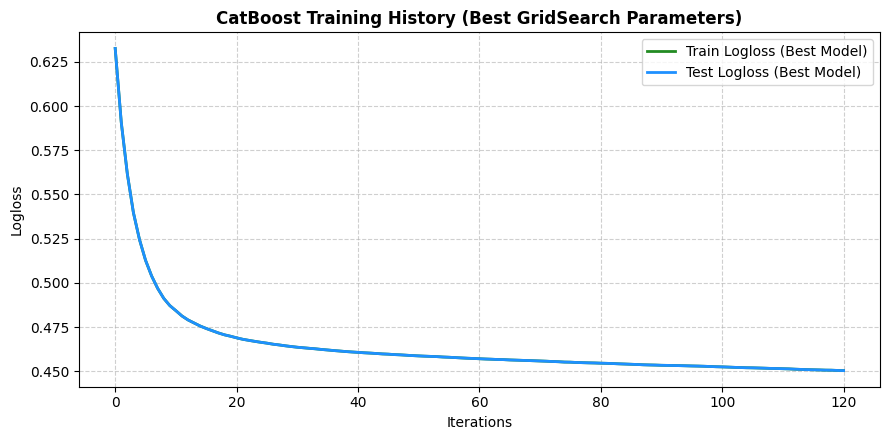

In [119]:
plt.figure(figsize=(9, 4.5)); plt.plot(train_metrics, label='Train Logloss (Best Model)', color='forestgreen', linewidth=2)
plt.plot(test_metrics, label='Test Logloss (Best Model)', color='dodgerblue', linewidth=2)
plt.title('CatBoost Training History (Best GridSearch Parameters)', fontsize=12, fontweight='bold')
plt.xlabel('Iterations', fontsize=10); plt.ylabel('Logloss', fontsize=10); plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout(); plt.show()

## XAI with CatBoost

In [127]:
X_test_df = pd.DataFrame(X_test, columns=X_train.columns)
explainer_cb23 = shap.Explainer(model_cb23)

# Calculate SHAP values using the explainer object directly on the DataFrame
shap_values_obj_23 = explainer_cb23(X_test_df)

<a id='Fig6'>Fig 6</a>: SHAP Beeswarm Plot <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>

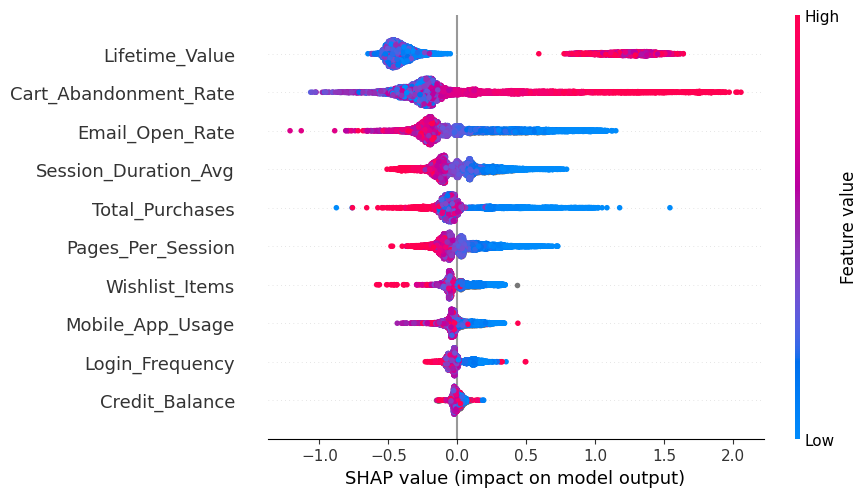

In [128]:
shap.plots.beeswarm(shap_values_obj_23)

Our strongest leading indicator is Cart_Abandonment_Rate. The red tail means that as a customer's cart abandoment rate increases, they're more likely to churn. 

Lifetime_Value is sending mixed signals. We have a clear split between the red in the positives and the blue in the negatives. The higher value spenders (in the red) seem to be kind of more likely to churn, and the churn rate stays a bit steadier at lower lifetime values (the blue), where the customers appear to be a bit more consistent.

Because the blue stretches to the right for email_open_rate and session_duration_average, the model seems to associate lower email engagement and shorter session times with an increased likelihood of churn. The red means those customers who open more emails and have longer sessions on the website are more likely to stay loyal.

Mobile_App_Usage, Login_Frequency and Credit_Balance all center pretty heavily around 0, so the model's least concerned about those and doesn't treat them with the same importance in terms of predictions.






<a id='Fig7'>Fig 7</a>: SHAP value for Cart_Abandonment_Rate <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>

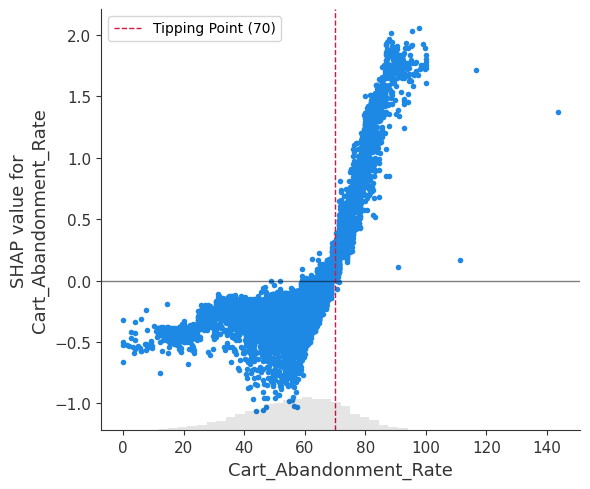

In [138]:
shap.plots.scatter(shap_values_obj_23[:, "Cart_Abandonment_Rate"], show=False)
plt.axvline(x=70, color='crimson', linestyle='--', linewidth=1, label='Tipping Point (70)')
plt.axhline(y=0.0, color='black', linestyle='-', linewidth=1, alpha=0.5)

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Our safe zone is below zero - above 0 is when the customers are more likely to churn.
There's a pretty sharp upturn between positive and negative association when Cart_Abandonment_Rate = 70, meaning that's about where our tipping point is. Once it goes above that, customers become alarmingly more likely to Churn.

This provides a really useful insight, actually - it could be something to pass on to the Marketing team. Once a customer's Cart Abandonment Rate crosses that 70 threshold, that's the time to act! Or... maybe before that.

<a id='Fig8'>Fig 8</a>: SHAP value for Lifetime_Value <span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>

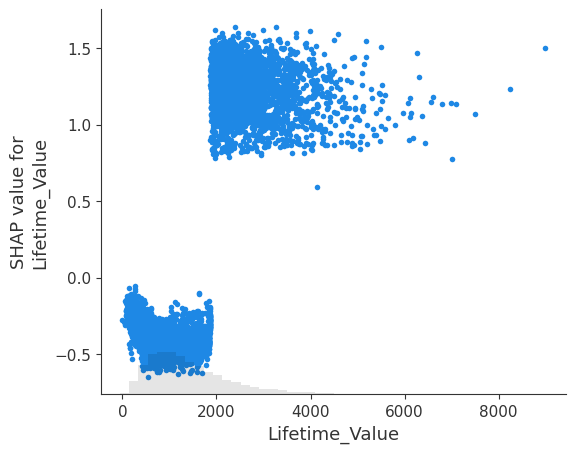

In [140]:
shap.plots.scatter(shap_values_obj_23[:, "Lifetime_Value"])

This doesn't seem... right. This looks like our data splits very cleanly and drastically at around Lifetime_Value = 2000, which is causing the model to effectively cleave its predictions in twain between 0 and +0.8.

Let's... take a closer look at what's happening around the 2000 mark.

<a id='fig8_additional'> </a>

In [151]:
below_2000 = X_test_df[X_test_df['Lifetime_Value'] < 2000]
above_2000 = X_test_df[X_test_df['Lifetime_Value'] >= 2000]
print("--- MEAN VALUES (LTV < 2000) --- \n", below_2000.mean(numeric_only=True))
print("\n--- MEAN VALUES (LTV >= 2000) --- \n", above_2000.mean(numeric_only=True))

--- MEAN VALUES (LTV < 2000) --- 
 Login_Frequency            10.035901
Session_Duration_Avg       25.150320
Pages_Per_Session           7.977168
Cart_Abandonment_Rate      60.312489
Wishlist_Items              3.677957
Total_Purchases            11.334010
Email_Open_Rate            18.258376
Mobile_App_Usage           17.318569
Lifetime_Value           1061.581647
Credit_Balance           1767.784006
dtype: float64

--- MEAN VALUES (LTV >= 2000) --- 
 Login_Frequency            17.315693
Session_Duration_Avg       36.225177
Pages_Per_Session          11.697793
Cart_Abandonment_Rate      45.482463
Wishlist_Items              6.462724
Total_Purchases            19.612287
Email_Open_Rate            30.641462
Mobile_App_Usage           26.839623
Lifetime_Value           2825.513659
Credit_Balance           2668.233248
dtype: float64


Ah, okay - so, the model seems to be somewhat confused about the big spenders. All the other metrics it's determined are "good" (like Cart_Abandonment_Rate and Session_Duration_Average) are consistent among the moneyed customers - they're more engaged, they're opening the emails, they make more purchases, and all, just like a customer who's not expected to Churn. But! They're still somehow churning, which doesn't fit the pattern that it recognises. That could be what's causing the model to split the data points the way it has for Lifetime_Value.

This might warrant reconsidering which features remain in the dataset - it might be an idea to drop Lifetime_Value and see what happens? Or another correlated value.

<span style="vertical-align: super; font-size: 0.7em;">([back to top](#part2))</span>